In [1]:
# dependencies imports and checks

import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
try:
  import mlflow
except:
  %pip install mlflow

try:
  import torchvision
except:
  %pip install torchvision

import torchvision
from torchvision import datasets
from torchvision import models
from torch.utils.data import DataLoader
from torchvision import transforms
from pathlib import Path
print(f"Pytorch version: {torch.__version__}\ntorchvision version:{torchvision.__version__}")

import glob

try:
  import torchinfo
except:
   %pip install torchinfo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 121.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 120.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 118.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!pwd

/content


In [3]:
!ls

sample_data


In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
import os
os.chdir("/content/drive/MyDrive/VLM_pipeline")
print(os.getcwd())

/content/drive/MyDrive/VLM_pipeline


In [6]:
# Modular imports
from data_setup import create_datasets, get_data
from engine import train
from utils import (save_model, load_model, display_random_images_from_dataset,
                   set_seed, pred_and_plot_image, plot_loss_acc_curves,
                   plot_random_images_from_path, get_device,
                   walk_through_dir)

In [7]:
device = get_device()
device

'cuda'

In [8]:
get_data()

/content/drive/MyDrive/VLM_pipeline/data/pizza_steak_sushi directory exists.


In [9]:
train_dir = Path('./data/pizza_steak_sushi/train')
test_dir = Path('./data/pizza_steak_sushi/test')

In [10]:
walk_through_dir(train_dir)

there are 3 directories and 0 images in inside data/pizza_steak_sushi/train directory
there are 0 directories and 78 images in inside data/pizza_steak_sushi/train/pizza directory
there are 0 directories and 75 images in inside data/pizza_steak_sushi/train/steak directory
there are 0 directories and 72 images in inside data/pizza_steak_sushi/train/sushi directory


In [11]:
walk_through_dir(test_dir)

there are 3 directories and 0 images in inside data/pizza_steak_sushi/test directory
there are 0 directories and 25 images in inside data/pizza_steak_sushi/test/pizza directory
there are 0 directories and 19 images in inside data/pizza_steak_sushi/test/steak directory
there are 0 directories and 31 images in inside data/pizza_steak_sushi/test/sushi directory


In [10]:
training_resolution = 224

vit_preprocess_transformations = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((training_resolution,training_resolution))
])

In [11]:
vit_train_dataloader, vit_test_dataloader, vit_class_names, vit_class_to_idx = create_datasets(
                    train_dir = train_dir,
                    test_dir = test_dir,
                    train_transformations = vit_preprocess_transformations,
                    test_transformations= vit_preprocess_transformations,
                    NUM_WORKERS= 0,
                    BATCH_SIZE = 32,
                    PIN_MEMORY = False,
                    DROP_LAST= True)

In [14]:
vit_train_dataloader

In [15]:
vit_class_to_idx, vit_class_names

({'pizza': 0, 'steak': 1, 'sushi': 2}, ['pizza', 'steak', 'sushi'])

In [16]:
len(next(iter(vit_test_dataloader))[0]), len(next(iter(vit_train_dataloader))[0])

(32, 32)

Text(0.5, 1.0, 'steak')

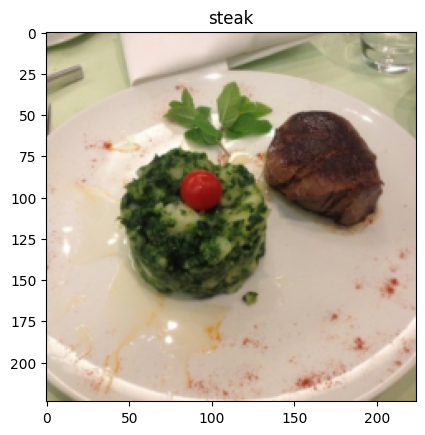

In [17]:
image_batch, label_batch = next(iter(vit_train_dataloader))

image, label = image_batch[0], label_batch[0]
plt.imshow(image.permute(1,2,0))
plt.title(vit_class_names[label])


In [18]:
image.ndim, image.shape, image.device

(3, torch.Size([3, 224, 224]), device(type='cpu'))

In [19]:
image

tensor([[[0.5153, 0.5830, 0.6424,  ..., 0.6371, 0.6507, 0.6558],
         [0.6623, 0.7039, 0.7366,  ..., 0.6429, 0.6484, 0.6626],
         [0.7210, 0.7195, 0.7061,  ..., 0.6399, 0.6558, 0.6706],
         ...,
         [0.6747, 0.6581, 0.6358,  ..., 0.6128, 0.6153, 0.6243],
         [0.6788, 0.6739, 0.6605,  ..., 0.6268, 0.6201, 0.6264],
         [0.6866, 0.6881, 0.6782,  ..., 0.6321, 0.6226, 0.6190]],

        [[0.4526, 0.5203, 0.5796,  ..., 0.6196, 0.6350, 0.6419],
         [0.5996, 0.6411, 0.6738,  ..., 0.6257, 0.6333, 0.6484],
         [0.6582, 0.6567, 0.6433,  ..., 0.6280, 0.6440, 0.6590],
         ...,
         [0.6414, 0.6277, 0.6116,  ..., 0.5665, 0.5696, 0.5786],
         [0.6437, 0.6403, 0.6301,  ..., 0.5740, 0.5673, 0.5736],
         [0.6513, 0.6530, 0.6449,  ..., 0.5772, 0.5677, 0.5641]],

        [[0.4016, 0.4693, 0.5286,  ..., 0.4871, 0.4899, 0.4876],
         [0.5486, 0.5901, 0.6228,  ..., 0.4997, 0.4958, 0.5025],
         [0.6042, 0.6027, 0.5893,  ..., 0.5060, 0.5179, 0.

In [20]:
patch_resolution = 16
# number of patches
num_patches = int(training_resolution * training_resolution) // (patch_resolution**2)
print(f"Number of patches: {num_patches}")

Number of patches: 196


In [21]:
print(f"image shape with dimensions as C,H,W: {image.shape}")

image shape with dimensions as C,H,W: torch.Size([3, 224, 224])


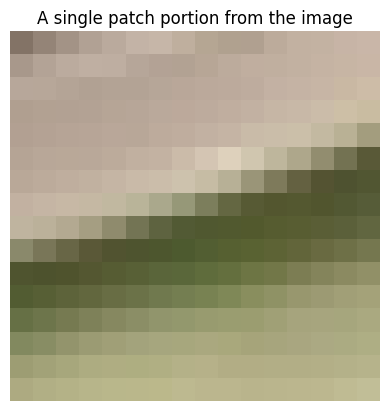

In [22]:
plt.axis(False)
plt.title("""A single patch portion from the image""")
plt.imshow(image.permute(1,2,0)[:patch_resolution,:patch_resolution,:])

In [23]:
# temp_image_unfold_test = image.unsqueeze(dim=0)
# unfold_layer = nn.Unfold(kernel_size=(patch_resolution,patch_resolution),stride = patch_resolution, dilation=1)
# a = unfold_layer(temp_image_unfold_test)
# a.shape

In [12]:
class PatchEmbeddings(nn.Module):

  def __init__(self,
               hidden_dimension:int=768,
               patch_resolution:int=16,
               in_channels:int=3):

    super().__init__()

    self.create_patches = nn.Unfold(kernel_size=(patch_resolution,patch_resolution),
                                                    stride=patch_resolution,
                                                    dilation=1)
  # torch.Size([1, 768, 196]) -> batchdim, number of pixels inside each flattened block, number of patches
    self.flattened_patch_size = int(in_channels * (patch_resolution**2))
    self.project_patches = nn.Linear(in_features=self.flattened_patch_size,
                                         out_features=hidden_dimension)

  def forward(self,x) -> torch.Tensor:
    x = self.create_patches(x)
    x = x.transpose(-2,-1)
    x = self.project_patches(x)
    return x
    # flatten -> linearly project

In [25]:
num_color_channels = image.shape[0]

In [26]:
image = image.unsqueeze(dim=0)

In [27]:
set_seed(42)

patch_embedding_projection_out_features = hidden_size = 768 # from table 1 ViT Base

patch_embedding_projection_in_features = (patch_resolution**2)*(num_color_channels) #P**2.C

single_patch_embedding = PatchEmbeddings(hidden_dimension=patch_embedding_projection_out_features,
                                         patch_resolution = patch_resolution,
                                         in_channels=num_color_channels)

In [28]:
test_patch_image = single_patch_embedding(image)

In [29]:
test_patch_image.shape

torch.Size([1, 196, 768])

Text(0.5, 1.0, 'First 16 pixels from the first patch')

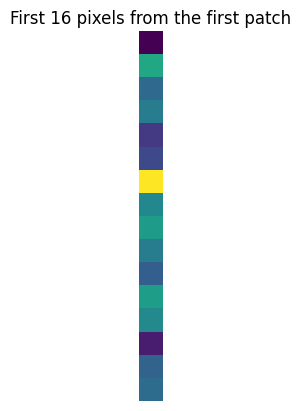

In [30]:
plt.imshow(test_patch_image.permute(1,2,0)[0,0:16,:].detach().numpy())
plt.axis(False)
plt.title("First 16 pixels from the first patch")

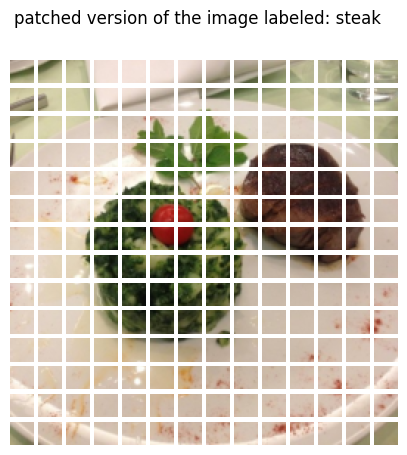

In [31]:
fig, ax = plt.subplots(14, 14, figsize=(5,5))
permute_image = image.squeeze(dim=0).permute(1,2,0)
for i in range(14):
  for j in range(14):
    ax[i,j].imshow(permute_image[(i * patch_resolution):((i+1)*patch_resolution),
                               (j * patch_resolution):((j+1)*patch_resolution),
                               :])
    ax[i,j].axis(False)
    plt.suptitle(f"patched version of the image labeled: {vit_class_names[label]}")

In [32]:
from torchinfo import summary

In [33]:
summary(single_patch_embedding,[1,3,224,224])

Layer (type:depth-idx)                   Output Shape              Param #
PatchEmbeddings                          [1, 196, 768]             --
├─Unfold: 1-1                            [1, 768, 196]             --
├─Linear: 1-2                            [1, 196, 768]             590,592
Total params: 590,592
Trainable params: 590,592
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.59
Input size (MB): 0.60
Forward/backward pass size (MB): 1.20
Params size (MB): 2.36
Estimated Total Size (MB): 4.17

In [34]:
# set_seed()
# class_token = nn.Parameter(torch.randn(1,1,hidden_size),requires_grad=True)
# # it should be batch_dimension in the first dim here but right now for debugging 1 also works
# class_token.shape

In [35]:
# test_patch_image.shape

In [36]:
# q = test_patch_image
# w = torch.cat((class_token,q),dim=1)
# w.shape

In [37]:
# position_embeddings = nn.Parameter(torch.randn(1,num_patches+1,hidden_size),requires_grad=True)
# position_embeddings.shape
# # it should be 32 here but right now for debugging 1 also works

In [38]:
# position_and_patch_embeddings = w + position_embeddings #final input to be gone into the transformer model.
# position_embeddings.shape

In [39]:
# compute self-attention using your custom layer. use reshape and transpose to do it in a single matrix and combine it together later on.
# position_and_patch_embeddings.shape

In [40]:
# number of heads = 12 from table 1
# 197 = N
# 768 = D

In [41]:
# self_attention_layer = SelfAttention(hidden_size = 768, KQV_projection_dim = 768)
# r = self_attention_layer(position_and_patch_embeddings)
# r.shape

In [42]:
# # position_and_patch_embeddings
# msa_block = MultiHeadAttention(num_heads=12, embed_size=768)
# h = msa_block(position_and_patch_embeddings)

In [43]:
# position_and_patch_embeddings.shape

In [44]:
# summary(MultiHeadAttention(num_heads=12, embed_size=768),[[1, 197, 768]])

In [45]:
# class SelfAttention(nn.Module):
#   def __init__(self, hidden_size: int , KQV_projection_dim:int):
#     super().__init__()

#     self.key_projection = nn.Linear(in_features=hidden_size,
#                                     out_features = KQV_projection_dim)

#     self.query_projection = nn.Linear(in_features=hidden_size,
#                                     out_features = KQV_projection_dim)

#     self.value_projection = nn.Linear(in_features=hidden_size,
#                                     out_features = KQV_projection_dim)

#     self.key_query_projection_dim = KQV_projection_dim

#   def forward(self,x) -> torch.Tensor:
#       Q = self.query_projection(x)
#       K = self.key_projection(x)
#       V = self.value_projection(x) #NxDv
#       K_t = K.transpose(-2,-1)

#       attention = torch.matmul(Q,K_t)

#       scaled_attention = attention / (self.key_query_projection_dim ** 0.5)

#       attention_weights = torch.softmax(scaled_attention,dim=-1) # NxN
#       weighted_values = torch.matmul(attention_weights,V)

#       return weighted_values

#   # optimizing it for lower training time

In [13]:

# N, num_patches, hidden_size
class MultiHeadAttention(nn.Module):
  def __init__(self, num_heads:int, embed_size: int):
    super().__init__()
    self.head_dimension = int(embed_size / num_heads)
    self.num_heads = num_heads
    # self.attention_heads = nn.ModuleList([SelfAttention(hidden_size = embed_size,
                                                # KQV_projection_dim = self.head_dimension) for i in range(num_heads)])
    
    self.final_linear_post_concat = nn.Linear(in_features=embed_size,out_features=embed_size)

    self.layer_norm = nn.LayerNorm(normalized_shape=embed_size)
    self.QKV_linear = nn.Linear(in_features= embed_size,
                                 out_features= int(3 * embed_size))

  def forward(self,x) -> torch.Tensor:
      x = self.layer_norm(x)
      N,num_patches, hidden_size = x.shape
      # N, num_patches, hidden_size ->  N, num_patches, 3 * hidden_size
      qkv_concat = self.QKV_linear(x)
      qkv_concat = qkv_concat.reshape(N, num_patches, 3, self.num_heads, self.head_dimension)

      Q,K,V = qkv_concat.permute(2,0,3,1,4)
      # (3,N,num_heads,num_patches,head_dim)

      K_t = K.transpose(-2,-1)
      attention = torch.matmul(Q,K_t)
      scaled_attention = attention / (self.head_dimension ** 0.5)
      attention_weights = torch.softmax(scaled_attention,dim=-1) # NxN
      weighted_values = torch.matmul(attention_weights,V)
      # (N,num_heads,num_patches,head_dim)
      concat_output = weighted_values.transpose(-3,-2).reshape(N,num_patches,hidden_size)

      # # N, num_patches, num_heads, head_dimension
      # pre_concat_output = []
      # for attention_block in self.attention_heads:
      #   pre_concat_output.append(attention_block(x))
      #   # check this
      # concat_output = torch.cat(pre_concat_output,dim=-1)
      final_output = self.final_linear_post_concat(concat_output)

      return final_output

In [14]:
# no dropout is mentioned for MSA and patch_embeddings in training in appendix b -> b.1
class MLPBlock(nn.Module):
  def __init__(self,embed_size:int=768,MLP_size:int=3072,dropout_rate:int=0.1):
    super().__init__()

    self.layer_norm = nn.LayerNorm(normalized_shape=embed_size)

    self.MLP = nn.Sequential(
        nn.Linear(in_features=embed_size,out_features=MLP_size),
        nn.GELU(),
        nn.Dropout(p=dropout_rate), # from table 3
        nn.Linear(in_features=MLP_size,out_features=embed_size),
        nn.Dropout(p=dropout_rate))

  def forward(self,x) -> torch.Tensor:
    post_MLP_output = self.MLP(self.layer_norm(x))
    return post_MLP_output

In [15]:
class TransformerEncoder(nn.Module):
  def __init__(self, hidden_size:int=768,
               MLP_size:int=3072,
               num_heads:int=12,
               dropout_rate:int=0.1):

    super().__init__()

    self.MSA = MultiHeadAttention(num_heads = num_heads,
                                  embed_size = hidden_size)

    self.MLP = MLPBlock(embed_size = hidden_size,
                        MLP_size=MLP_size,
                        dropout_rate=dropout_rate)

  def forward(self,x) -> torch.Tensor:
    # N, num_patches, patch_embedding_projection_out_features .....dimensions of x -> N, num_patches, patch_embedding_projection_out_features
    msa_residual_output = self.MSA(x) + x
    # N, num_patches, patch_embedding_projection_out_features
    mlp_residual_output = self.MLP(msa_residual_output) + msa_residual_output

    return mlp_residual_output

In [16]:
class ViT(nn.Module):
  def __init__(self,
               patch_projection_size:int=768,
               patch_resolution:int=16,
               BATCH_SIZE:int=64,
               num_patches:int=196,
               in_channels:int=3,
               num_transformer_layers:int=12,
               dropout_rate:int=0.1,
               num_heads:int=12,
               MLP_size:int=3072,
               num_classes:int = 10
               ):
    # Change the parameter and see once how it is working.
    # number of tansformer encoder layers/blocks in base model ViT is 12
    super().__init__()

    self.patch_embedding = PatchEmbeddings(in_channels= in_channels,
                                           hidden_dimension=patch_projection_size,
                                           patch_resolution=patch_resolution)

    self.class_token = nn.Parameter(torch.randn(1,1,patch_projection_size),
                                    requires_grad=True)

    self.position_embeddings = nn.Parameter(torch.randn(1,num_patches+1,
                                                   patch_projection_size),
                                       requires_grad=True)

    self.transformer_layers = nn.ModuleList([TransformerEncoder(hidden_size=patch_projection_size,
                                                                MLP_size=MLP_size,
                                                                num_heads=num_heads,
                                                                # output dimension of patches = input dimension of MSA
                                                                dropout_rate=dropout_rate)
                                                                for _ in range(num_transformer_layers)])

    self.transformer_sequence = nn.Sequential(*self.transformer_layers)

    self.MLP_head = nn.Sequential(
        nn.LayerNorm(normalized_shape = patch_projection_size),
        nn.Linear(in_features = patch_projection_size,
                  out_features = num_classes)
    )
    self.batch_size = BATCH_SIZE

  def forward(self, x) -> torch.Tensor:
    # N = BATCH_SIZE
    # NCHW -> N,num_patches,P**2.C -> N,num_patches,patch_projection_size
    flattened_patch_embeddings = self.patch_embedding(x)
    # check the flattened patch_embeddings here
    # N, num_patches, patch_projection_size -> N, num_patches, patch_projection_size
    class_embed = self.class_token.expand(self.batch_size,-1,-1)

    position_embeddings = self.position_embeddings.expand(self.batch_size,-1,-1)
    
    position_and_patch_embeddings = torch.cat((class_embed,
                                               flattened_patch_embeddings),dim=1) + position_embeddings

    # N, num_patches, patch_projection_size -> N, num_patches, patch_projection_size
    pre_MLP_HEAD_output = self.transformer_sequence(position_and_patch_embeddings)

    # accessing all the very first tokens and it's embeddings to get class_token_embeddings through the batch
    pred_logits = self.MLP_head(pre_MLP_HEAD_output[:,0])

    return pred_logits



In [50]:
from torch.profiler import profile, ProfilerActivity, record_function

In [26]:
set_seed(42)

ViT_model = ViT(patch_projection_size=768,
               patch_resolution=16,
               BATCH_SIZE=32,
               num_patches=196,
               in_channels=3,
               num_transformer_layers=12,
               dropout_rate=0.1,
               num_heads=12,
               MLP_size=3072,
               num_classes = 10)

In [55]:
# del ViT_model
import gc
gc.collect()

0

In [34]:
# gc.collect()

In [35]:
# patch_embedding_projection_out_features = hidden_size = 768 # from table 1 ViT Base

# patch_embedding_projection_in_features = (patch_resolution**2)*(num_color_channels) #P**2.C

# single_patch_embedding = PatchEmbeddings(flattened_patch_size= patch_embedding_projection_in_features,
#                                          hidden_dimension=patch_embedding_projection_out_features)

# set_seed()
# class_token = nn.Parameter(torch.randn(1,1,hidden_size),requires_grad=True)
# position_embeddings = nn.Parameter(torch.randn(1,num_patches+1,hidden_size),requires_grad=True)

# q = test_patch_image # test_patch_image = single_patch_image
# w = torch.cat((class_token,q),dim=1)
# position_and_patch_embeddings = w + position_embeddings #final input to be gone into the transformer model.

In [56]:
for i, (X,y) in enumerate(vit_train_dataloader):
    print(f"Train batch {i+1}")
    print(X.shape, y.shape)

for i,(X,y) in enumerate(vit_test_dataloader):
    print(f"Test batch {i+1}")
    print(X.shape, y.shape)

Train batch 1
torch.Size([32, 3, 224, 224]) torch.Size([32])
Train batch 2
torch.Size([32, 3, 224, 224]) torch.Size([32])
Train batch 3
torch.Size([32, 3, 224, 224]) torch.Size([32])
Train batch 4
torch.Size([32, 3, 224, 224]) torch.Size([32])
Train batch 5
torch.Size([32, 3, 224, 224]) torch.Size([32])
Train batch 6
torch.Size([32, 3, 224, 224]) torch.Size([32])
Train batch 7
torch.Size([32, 3, 224, 224]) torch.Size([32])
Test batch 1
torch.Size([32, 3, 224, 224]) torch.Size([32])
Test batch 2
torch.Size([32, 3, 224, 224]) torch.Size([32])


In [57]:
debug_train_batch = next(iter(vit_train_dataloader))
# a = ViT_model()

In [58]:
debug_train_batch_images_temp = debug_train_batch[0]
# debug_train_batch_images_temp_logits = ViT_model(debug_train_batch_images_temp)

In [59]:
ViT_model.eval()
with torch.inference_mode():
    debug_train_batch_images_temp_logits = ViT_model(debug_train_batch_images_temp)

In [60]:
debug_train_batch_images_temp_logits.shape

torch.Size([32, 10])

In [58]:
with profile(activities=[ProfilerActivity.CPU],record_shapes=True) as prof:
  with record_function("model_debug_CPU_RAM"):
    ViT_model.train()
    ViT_model(debug_train_batch_images_temp)

In [59]:
print(prof.key_averages().table(sort_by="cpu_time_total",row_limit=10))

---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                       Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
        model_debug_CPU_RAM         1.29%      37.212ms       100.00%        2.891s        2.891s             1  
               aten::linear         0.09%       2.482ms        59.47%        1.719s      21.494ms            80  
                aten::addmm        52.90%        1.529s        57.05%        1.649s      20.879ms            79  
              aten::dropout         0.01%     288.439us        25.13%     726.602ms     181.651ms             4  
           aten::bernoulli_        20.82%     601.898ms        20.82%     601.898ms     150.474ms             4  
               aten::matmul         0.05%       1.336ms         5.69%     164.452ms     

In [ ]:
with profile(activities=[ProfilerActivity.CPU],record_shapes=True) as prof2:
  with record_function("model_debug_test_CPU_RAM"):
    ViT_model.eval()
    with torch.inference_mode():
      ViT_model(debug_train_batch_images_temp)

In [49]:
print(prof2.key_averages().table(sort_by="cpu_time_total",row_limit=10))

----------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                        Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
----------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
    model_debug_test_CPU_RAM         1.04%      44.030ms       100.00%        4.242s        4.242s             1  
                aten::linear         0.09%       3.821ms        80.92%        3.433s      42.910ms            80  
                 aten::addmm        70.91%        3.008s        77.28%        3.278s      41.500ms            79  
                aten::matmul         0.05%       2.309ms         7.92%     336.040ms       6.858ms            49  
                 aten::copy_         7.21%     305.868ms         7.21%     305.868ms       2.913ms           105  
                   aten::bmm         4.38%     185.618ms         4.38%     185.6

In [34]:
debug_train_batch_images_temp.shape

torch.Size([32, 3, 224, 224])

In [35]:
debug_train_batch_images_temp_logits.shape

torch.Size([32, 10])

In [36]:
debug_train_batch_labels = debug_train_batch[1]
debug_train_batch_labels.shape

torch.Size([32])

In [61]:
debug_train_batch2 = next(iter(vit_train_dataloader))
debug_train_batch2_images = debug_train_batch2[0]
debug_train_batch2_labels = debug_train_batch2[1]

In [62]:
debug_train_batch2_images.shape

torch.Size([32, 3, 224, 224])

In [63]:
ViT_model.eval()
with torch.inference_mode():
  debug_train_batch_2_images_temp_logits = ViT_model(debug_train_batch2_images)

In [64]:
debug_train_batch_2_images_temp_logits.shape

torch.Size([32, 10])

In [82]:
count = 0
for X,y in vit_test_dataloader:
    count+=1
    print(X.shape)
    print(y.shape)
    # test_dataloader= vit_test_dataloader

torch.Size([32, 3, 224, 224])
torch.Size([32])
torch.Size([32, 3, 224, 224])
torch.Size([32])
torch.Size([11, 3, 224, 224])
torch.Size([11])


In [21]:
from torch.profiler import profile, ProfilerActivity, record_function

In [27]:
# Vanilla ViT
from tqdm.auto import tqdm
from engine import train
from utils import get_device

device = get_device()
NUM_EPOCHS = 5

vit_optimizer = torch.optim.Adam(params = ViT_model.parameters(),
                                 lr=0.01,
                                  betas=(0.9,0.999),
                                  weight_decay=0.1)

vit_loss_fn = torch.nn.CrossEntropyLoss()

with profile(activities=[ProfilerActivity.CPU],record_shapes=True) as vit_train_profiler:
  with record_function("vit_train__optimizing_debug"):
           vit_train_results = train(model = ViT_model,
                train_dataloader= vit_train_dataloader,
                test_dataloader= vit_test_dataloader,
                optimizer= vit_optimizer,
                device = device,
                loss_fn= vit_loss_fn,
                epochs=NUM_EPOCHS
                )

  0%|          | 0/5 [00:00<?, ?it/s]

Completed 1 batch out of 7 for training
Completed 2 batch out of 7 for training
Completed 3 batch out of 7 for training
Completed 4 batch out of 7 for training
Completed 5 batch out of 7 for training
Completed 6 batch out of 7 for training
Completed 7 batch out of 7 for training
Completed 1 batch out of 2 for testing
Completed 2 batch out of 2 for testing
Epoch: 1 | train_loss: 4.2247 | train_acc: 0.2723 | test_loss: 3.2935 | test_acc: 0.2969
Completed 1 batch out of 7 for training
Completed 2 batch out of 7 for training
Completed 3 batch out of 7 for training
Completed 4 batch out of 7 for training
Completed 5 batch out of 7 for training
Completed 6 batch out of 7 for training
Completed 7 batch out of 7 for training
Completed 1 batch out of 2 for testing
Completed 2 batch out of 2 for testing
Epoch: 2 | train_loss: 1.9351 | train_acc: 0.3080 | test_loss: 1.1620 | test_acc: 0.2969
Completed 1 batch out of 7 for training
Completed 2 batch out of 7 for training
Completed 3 batch out of 7

In [28]:
print(vit_train_profiler.key_averages().table(sort_by="cpu_time_total",row_limit=10))

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                            vit_train__optimizing_debug         2.47%        1.555s        98.48%       62.107s       62.107s             1  
                                             aten::item         0.03%      18.917ms        74.03%       46.689s       4.345ms         10745  
                              aten::_local_scalar_dense         0.01%       9.383ms        74.00%       46.670s       4.343ms         10745  
                                  cudaStreamSynchronize        73.99%       46.664s        73.99%       46.664s     140.555ms           332  
enumer

In [29]:
# plot_loss_acc_curves(results)


In [ ]:

# Print confusion matrix of the model

# %matplotlib inline
# from sklearn.metrics import confusion_matrix
# import seaborn as sn
# import pandas as pd

# y_pred = []
# y_true = []

# # iterate over test data
# for inputs, labels in tqdm(test_dataloader):
#         loaded_model.to(device), inputs.to(device), labels.to(device)
#         output = loaded_model(inputs) # Feed Network

#         pred_logits = torch.softmax(output,dim=1)
#         pred_labels = torch.argmax(pred_logits,dim=1).data.cpu().numpy()
#         y_pred.extend(pred_labels) # Save Prediction

#         labels = labels.data.cpu().numpy()
#         y_true.extend(labels) # Save Truth

# classes = class_names

# cf_matrix = confusion_matrix(y_true, y_pred)
# df_cm = pd.DataFrame(cf_matrix , index = [i for i in classes],
#                      columns = [i for i in classes])
# plt.figure(figsize = (12,7))
# ax = sn.heatmap(df_cm, annot=True, cmap='Set2')
# ax.set(xlabel='Predicted labels',ylabel='True labels')
# plt.show()

In [28]:
# from datetime import datetime
# model_name = '5_epochs_'+ datetime.now().strftime('%Y_Y_%m_m_%d_d_%H:%M:%S')+'_VGG16MINI.pth'
# save_model(model=model,
#            target_dir='/content/models',
#            model_name=model_name)


In [27]:
# !rm -rf /content/drive/MyDrive/VLM_pipeline/data/pizza_steak_sushi